# Лабораторная работа 2. Нейронные сети и компьютерное зрение.

Результатом лабораторной работы является отчет. Мы предпочитаем принимать отчеты в формате ноутбуков IPython (ipynb-файл). Постарайтесь сделать ваш отчет интересным рассказом, последовательно отвечающим на вопросы из заданий. Помимо ответов на вопросы, в отчете также должен быть код, однако чем меньше кода, тем лучше всем: нам — меньше проверять, вам — проще найти ошибку или дополнить эксперимент. При проверке оценивается четкость ответов на вопросы, аккуратность отчета и кода.

Мы уверены, что выполнение лабораторных работ занимает значительное время, поэтому не рекомендуем оставлять их на последний вечер перед сдачей.


# Часть 1. Свёрточные сети (14.5 баллов)

Здесь вам предстоит построить и обучить свою первую свёрточную сеть для классификации изображений на данных CIFAR10. 

## Данные

CIFAR10
* 60000 RGB изображений размером 32x32x3
* 10 классов: самолёты, собаки, рыбы и т.п.

<img src="https://www.samyzaf.com/ML/cifar10/cifar1.jpg" style="width:60%">

Загрузите данные, разделите их на обучающую и тестовую выборки. Размер тестовой выборки должен быть 10^4.

In [330]:
import numpy as np
from keras.datasets import cifar10
from sklearn.model_selection import train_test_split
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=10**4, random_state=42)

class_names = np.array(['airplane','automobile ','bird ','cat ','deer ','dog ','frog ','horse ','ship ','truck'])

print (X_train.shape, y_train.shape)

(40000, 32, 32, 3) (40000, 1)


In [331]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from tqdm.notebook import trange

Создаём отдельные датасеты с аугментацией, для последнего задания

In [332]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
], seed=1337, strict=True)

In [333]:
X_train_aug = []
y_train_aug = []

for i in range(len(X_train)):
    img = X_train[i]
    label = y_train[i]

    for _ in range(3):

        aug = transform(image=img)["image"]
        aug = torch.tensor(aug).permute(2,0,1)

        X_train_aug.append(aug)
        y_train_aug.append(label)

In [334]:
X_train_aug = torch.tensor(np.array(X_train_aug).astype(np.float32) / 255.)
y_train_aug = torch.tensor(np.array(y_train_aug).astype(np.uint8)).reshape(-1)

X_train_aug, y_train_aug

(tensor([[[[0.1333, 0.1451, 0.1725,  ..., 0.2431, 0.2039, 0.1765],
           [0.1373, 0.1333, 0.1333,  ..., 0.2275, 0.1961, 0.1843],
           [0.1333, 0.1294, 0.1294,  ..., 0.2588, 0.2000, 0.2078],
           ...,
           [0.1255, 0.1255, 0.1294,  ..., 0.1608, 0.1333, 0.1412],
           [0.1294, 0.1255, 0.1333,  ..., 0.1451, 0.1255, 0.1176],
           [0.1451, 0.1451, 0.1451,  ..., 0.1922, 0.1843, 0.2275]],
 
          [[0.1412, 0.1451, 0.1725,  ..., 0.2863, 0.2471, 0.2235],
           [0.1373, 0.1333, 0.1294,  ..., 0.2706, 0.2353, 0.2275],
           [0.1294, 0.1255, 0.1255,  ..., 0.3020, 0.2431, 0.2510],
           ...,
           [0.1255, 0.1216, 0.1294,  ..., 0.1490, 0.1216, 0.1255],
           [0.1216, 0.1176, 0.1255,  ..., 0.1373, 0.1137, 0.1098],
           [0.1255, 0.1255, 0.1294,  ..., 0.1843, 0.1765, 0.2196]],
 
          [[0.1686, 0.2000, 0.2510,  ..., 0.3647, 0.3255, 0.3020],
           [0.1451, 0.1569, 0.1686,  ..., 0.3490, 0.3137, 0.3059],
           [0.1373, 0.14

In [335]:
X_train_aug.shape, y_train_aug.shape

(torch.Size([120000, 3, 32, 32]), torch.Size([120000]))

Датасет также доступен по ссылке [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html). В PyTorch нужно использовать [torchvision.datasets](https://pytorch.org/vision/stable/datasets.html) и разбить его на обучающую, валидационную и тестовую выборки.

**Замечание:** По умолчанию данные в PyTorch разбиты на обучающую и тестовую выборки. Для того что бы разбить обучающую выборку на обучающую и валидационную, можно воспользоваться [torch.utils.data.sampler.SubsetRandomSampler](https://pytorch.org/docs/stable/data.html#torch.utils.data.SubsetRandomSampler).

Прежде, чем приступать к основной работе, стоит убедиться, что загруженно именно то, что требовалось:

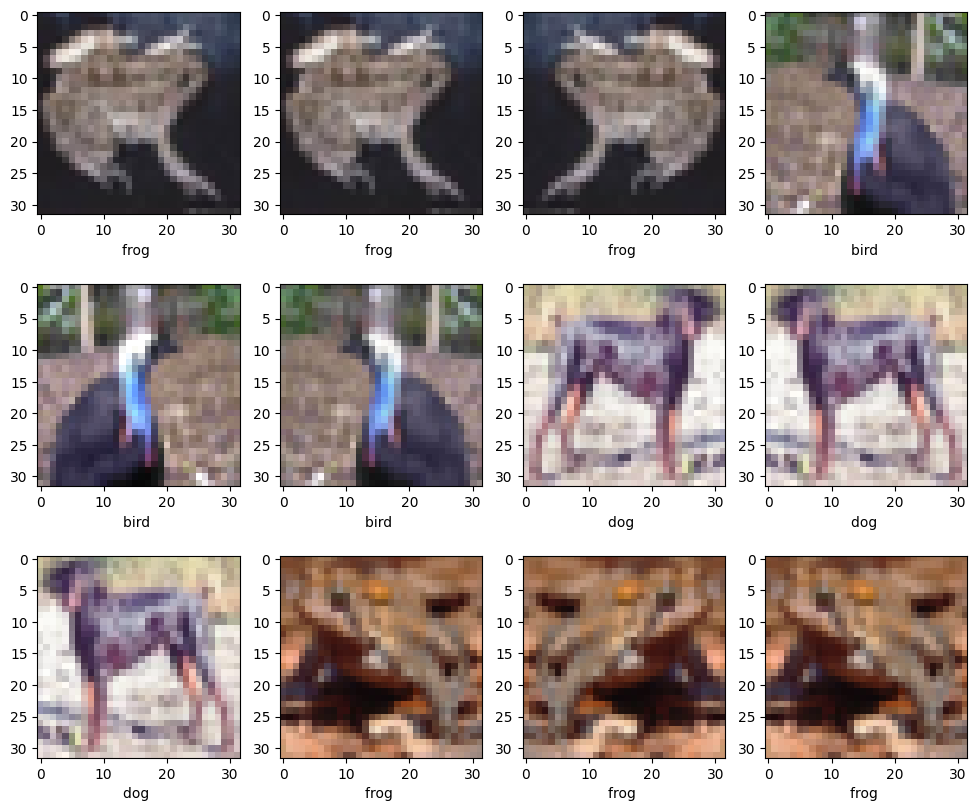

In [336]:
import matplotlib.pyplot as plt

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.xlabel(class_names[y_train_aug[i]])
    plt.imshow(X_train_aug[i].permute((1, 2, 0)))

## Подготовка данных

Сейчас каждый пиксель изображения закодирован тройкой чисел (RGB) __от 0 до 255__. Однако лучше себя показывает подход, где значения входов нейросети распределены недалеко от 0.

Давайте приведём все данные в диапазон __`[0, 1]`__ — просто разделим на соответствующий коэффициент:

In [337]:
X_train = X_train.astype(np.float32) / 255.
X_val = X_val.astype(np.float32) / 255.
X_test = X_test.astype(np.float32) / 255.

Исполните код ниже для проверки, что все выполнено корректно.

In [338]:
assert np.shape(X_train) == (40000, 32, 32, 3), "data shape should not change"
assert 0.9 <= max(map(np.max, (X_train, X_val, X_test))) <= 1.05
assert 0.0 <= min(map(np.min, (X_train, X_val, X_test))) <= 0.1
assert len(np.unique(X_test / 255.)) > 10, "make sure you casted data to float type"

In [339]:
X_train, y_train, X_val, y_val, X_test, y_test = map(torch.tensor, [
        X_train, y_train.reshape(-1), 
        X_val, y_val.reshape(-1), 
        X_test, y_test.reshape(-1)
    ])

## Архитектура сети

Для начала реализуйте простую нейросеть:
1. принимает на вход картинки размера 32 x 32 x 3;
2. вытягивает их в вектор (`torch.nn.Flatten`);
3. пропускает через 1 или 2 полносвязных слоя;
4. выходной слой отдает вероятности принадлежности к каждому из 10 классов.

Создайте полносвязную сеть:

In [7]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [340]:
train_ds = TensorDataset(X_train, y_train)
valid_ds = TensorDataset(X_val, y_val)
train_aug_ds = TensorDataset(X_train_aug, y_train_aug)

def get_data(batch_size: int, train_ds, valid_ds):
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(valid_ds, batch_size=batch_size, shuffle=True)
    )

In [9]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.process = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(3072, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
            nn.Softmax(1)
        )
    
    def forward(self, xb) -> torch.Tensor:
        return self.process(xb)
    
    def predict_proba(self, xb):
        return self.forward(xb)
    
    def predict_classes(self, xb):
        return self.forward(xb).argmax(dim=1)


def get_model(lr):
    model = SimpleNN()
    return model.to(device), optim.SGD(model.parameters(), lr=lr)

In [10]:
model, opt = get_model(lr=0.001)

In [11]:
dummy_pred = model.predict_proba(X_train[:20].to(device))
assert dummy_pred.shape == (20, 10)
assert torch.allclose(dummy_pred.sum(-1), torch.tensor(1.))
print("Успех!")

Успех!


## Обучение сети

**Задание 1(1.5 балла).** Будем минимизировать многоклассовую кроссэкнропию с помощью __sgd__. Добавьте расписание для learning rate в финальную версию. Вам нужно получить сеть, которая достигнет __не менее 45%__ __accuracy__ на тестовых данных.

В PyTorch есть модуль [tensorboard](https://pytorch.org/docs/stable/tensorboard.html),  который по сути использует готовый (установленный вами) TensorBoard, так что в вопросе визуализации PyTorch несколько проигрывает Tensorflow, но, тем не менее, благодаря данному модулю все возможности Tensorboard досутпны и в PyTorch

In [315]:
def loss_batch(model, loss_func, xb, yb, opt=None):
    loss = loss_func(model(xb), yb)
    
    if opt is not None:
        loss.backward()
        opt.step()
        opt.zero_grad()
    
    return loss.item(), xb.shape[0]
    

def fit(
    epochs: int,
    model: nn.Module,
    loss_func,
    opt,
    train_dl,
    valid_dl,
    writer,
    lr_scheduler = None,
    verbose: bool = False
):
    
    model = model.to(device)
    for epoch in trange(epochs):
        train_losses = []
        val_losses = []
        val_acc = 0
        
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            loss, b_size = loss_batch(model, loss_func, xb, yb, opt)
            train_losses.append(loss * b_size)
        
        model.eval()
        with torch.no_grad():
            correct = 0
            total_val = 0
            
            for xb, yb in valid_dl:
                xb, yb = xb.to(device), yb.to(device)
                
                loss, b_size = loss_batch(model, loss_func, xb, yb)
                val_losses.append(loss * b_size)
                
                correct += (model.predict_classes(xb) == yb).sum()
                total_val += b_size
            
                
        
        
        train_loss = float(torch.sum(torch.as_tensor(train_losses)) / len(train_dl))
        val_loss = float(torch.sum(torch.as_tensor(val_losses)) / len(valid_dl))
        val_acc = correct / total_val
        
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        writer.add_scalar("Acc/val", val_acc, epoch)
        
        if verbose:
            curr_lr = opt.param_groups[0]["lr"]
            print(f"Epoch: {epoch:03d} "
                f"Train_loss: {train_loss:.4f} "
                f"Val_loss: {val_loss:.4f} "
                f"Val_acc: {val_acc:.4f} "
                f"LR: {curr_lr:.2e}")
        
        if lr_scheduler:
            lr_scheduler.step(val_loss)
    
    writer.close()



Добавил ниже ```SummaryWriter``` для tensorboard и ```lr_scheduler``` для динамического изменения lr

In [ ]:
train_dl, val_dl = get_data(128, train_ds, valid_ds)
model, opt = get_model(lr=0.1)
writer = SummaryWriter("runs/SimpleNN")
scheduler = ReduceLROnPlateau(opt, 'min', factor=0.1, patience=10)

fit(100, model, F.cross_entropy, opt, train_dl, val_dl, writer, scheduler, verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 000 Train_loss: 287.0510 Val_loss: 278.2248 Val_acc: 0.2635 LR: 1.00e-01
Epoch: 001 Train_loss: 278.0506 Val_loss: 273.6718 Val_acc: 0.3022 LR: 1.00e-01
Epoch: 002 Train_loss: 274.5173 Val_loss: 272.5430 Val_acc: 0.3007 LR: 1.00e-01
Epoch: 003 Train_loss: 272.0485 Val_loss: 270.3988 Val_acc: 0.3236 LR: 1.00e-01
Epoch: 004 Train_loss: 270.0747 Val_loss: 267.7665 Val_acc: 0.3426 LR: 1.00e-01
Epoch: 005 Train_loss: 268.7004 Val_loss: 268.4914 Val_acc: 0.3328 LR: 1.00e-01
Epoch: 006 Train_loss: 267.6721 Val_loss: 266.2343 Val_acc: 0.3575 LR: 1.00e-01
Epoch: 007 Train_loss: 266.7278 Val_loss: 266.0195 Val_acc: 0.3525 LR: 1.00e-01
Epoch: 008 Train_loss: 265.9872 Val_loss: 265.0223 Val_acc: 0.3629 LR: 1.00e-01
Epoch: 009 Train_loss: 265.4100 Val_loss: 263.5493 Val_acc: 0.3759 LR: 1.00e-01
Epoch: 010 Train_loss: 264.7560 Val_loss: 263.7541 Val_acc: 0.3745 LR: 1.00e-01
Epoch: 011 Train_loss: 264.0034 Val_loss: 262.7492 Val_acc: 0.3813 LR: 1.00e-01
Epoch: 012 Train_loss: 263.4854 Val_loss

А теперь можно проверить качество вашей сети, выполнив код ниже:

In [14]:
from sklearn.metrics import accuracy_score

model = model.to("cpu")
test_acc = accuracy_score(y_test, model.predict_classes(X_test))
print("\n Test_acc =", test_acc)
assert test_acc > 0.45, "Not good enough. Back to the drawing board :)"
print(" Not bad!")


 Test_acc = 0.4959
 Not bad!


## Карманная сверточная сеть

**Задание 2 (1.5 балла).** Реализуйте небольшую свёрточную сеть. Совсем небольшую:
1. Входной слой
2. Свёртка 3x3 с 10 фильтрами
3. Нелинейность на ваш вкус
4. Max-pooling 2x2
5. Вытягиваем оставшееся в вектор (Flatten)
6. Полносвязный слой на 100 нейронов
7. Нелинейность на ваш вкус
8. Выходной полносвязный слой с softmax

Обучите её так же, как и предыдущую сеть. Если всё хорошо, у вас получится accuracy не меньше __50%__.

Переведём выборки из формата размерностей ```WHC``` в ```CHW```, чтобы в PyTorch правильно работала свёртка

In [341]:
X_train = X_train.permute(0, 3, 1, 2)
X_val = X_val.permute(0, 3, 1, 2)
X_test = X_test.permute(0, 3, 1, 2)

In [342]:
X_train.shape, X_test.shape, X_val.shape

(torch.Size([40000, 3, 32, 32]),
 torch.Size([10000, 3, 32, 32]),
 torch.Size([10000, 3, 32, 32]))

In [343]:
train_ds = TensorDataset(X_train, y_train)
valid_ds = TensorDataset(X_val, y_val)

In [344]:
train_dl, val_dl = get_data(batch_size=128, train_ds=train_ds, valid_ds=valid_ds)

In [19]:
class PocketCNN(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=10,
                kernel_size=3
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(2250, 100),
            nn.ReLU(),
            nn.Linear(100, 10)
        )
    
    def forward(self, xb) -> torch.Tensor:
        features  = self.features(xb)
        return self.classifier(features)
    
    def predict_proba(self, xb):
        return self.forward(xb)
    
    def predict_classes(self, xb):
        return self.forward(xb).argmax(dim=1)


In [ ]:
model = PocketCNN()
opt = torch.optim.SGD(model.parameters(), lr=0.1)
scheduler = ReduceLROnPlateau(opt, "min", factor=0.1, patience=10)
writer = SummaryWriter("runs/SimpleCNN")

fit(100, model, F.cross_entropy, opt, train_dl, val_dl, writer, scheduler, verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 000 Train_loss: 257.2283 Val_loss: 237.4323 Val_acc: 0.3177 LR: 1.00e-01
Epoch: 001 Train_loss: 211.0709 Val_loss: 193.5426 Val_acc: 0.4517 LR: 1.00e-01
Epoch: 002 Train_loss: 185.2506 Val_loss: 223.3056 Val_acc: 0.3992 LR: 1.00e-01
Epoch: 003 Train_loss: 169.5309 Val_loss: 178.0714 Val_acc: 0.5044 LR: 1.00e-01
Epoch: 004 Train_loss: 158.5029 Val_loss: 163.4586 Val_acc: 0.5449 LR: 1.00e-01
Epoch: 005 Train_loss: 150.9053 Val_loss: 165.1514 Val_acc: 0.5433 LR: 1.00e-01
Epoch: 006 Train_loss: 142.0595 Val_loss: 162.6871 Val_acc: 0.5494 LR: 1.00e-01
Epoch: 007 Train_loss: 134.6510 Val_loss: 152.2026 Val_acc: 0.5801 LR: 1.00e-01
Epoch: 008 Train_loss: 127.6429 Val_loss: 146.6913 Val_acc: 0.6006 LR: 1.00e-01
Epoch: 009 Train_loss: 121.7786 Val_loss: 152.8221 Val_acc: 0.5854 LR: 1.00e-01
Epoch: 010 Train_loss: 115.8231 Val_loss: 168.9512 Val_acc: 0.5624 LR: 1.00e-01
Epoch: 011 Train_loss: 110.6542 Val_loss: 155.7801 Val_acc: 0.5918 LR: 1.00e-01
Epoch: 012 Train_loss: 104.5704 Val_loss

Давайте посмотрим, смогла ли карманная сверточная сеть побить заданный порог по качеству:

In [21]:
from sklearn.metrics import accuracy_score

model.to("cpu")
test_acc = accuracy_score(y_test.to("cpu"), model.predict_classes(X_test.to("cpu")))
print("\n Test_acc =", test_acc)
assert test_acc > 0.50, "Not good enough. Back to the drawing board :)"
print(" Not bad!")


 Test_acc = 0.5941
 Not bad!


## Учимся учить

А теперь научимся сравнивать кривые обучения моделей — зависимости значения accuracy от количества итераций. 

Вам потребуется реализовать _экспериментальный стенд_ — вспомогательный код, в который вы сможете подать несколько архитектур и методов обучения, чтобы он их обучил и вывел графики кривых обучения. `TensorBoard` или `W&B` (нужно будет приложить открытую ссылку на результаты ранов).

Будьте морально готовы, что на обучение уйдёт _много времени_. Даже если вы ограничитесь 10 эпохами. Пока идёт обучение, вы можете переключиться на другие задания или заняться чем-нибудь приятным: поспать, например.

In [345]:
from collections.abc import Callable
from torch.utils.tensorboard import SummaryWriter
from joblib import Parallel, delayed


def run_one_model_experiment(
    create_model: Callable[[], nn.Module],
    loss_func: F,
    
    train_dl: DataLoader,
    val_dl: DataLoader,
        
    create_opt: Callable,
    opt_args: dict,
    is_scheduler: bool,
    
    epochs: int,
    experiment_name: str,
    experiments: str
):
    
    model = create_model()
    opt = create_opt(model.parameters(), **opt_args)
    scheduler = ReduceLROnPlateau(opt, "min", factor=0.1) if is_scheduler else None
    writer = SummaryWriter(log_dir=f"runs/{experiments}/{experiment_name}")
    
    fit(epochs, model, loss_func, opt, train_dl, val_dl, writer, scheduler)
    


def run_experiments(experiments_dict: dict, experiments_name: str):
    
    # for expr_name, d in experiments_dict.items():
    #     run_one_model_experiment(
    #             d["create_model"],
    #             d["loss_func"],
    #             d["train_dl"],
    #             d["val_dl"],
    #             d["create_opt"],
    #             d["opt_args"],
    #             d["is_scheduler"],
    #             d["epochs"],
    #             expr_name,
    #             experiments_name
    #     )
        
        
    Parallel(n_jobs=5)(
        delayed(run_one_model_experiment)(
            d["create_model"],
            d["loss_func"],
            d["train_dl"],
            d["val_dl"],
            d["create_opt"],
            d["opt_args"],
            d["is_scheduler"],
            d["epochs"],
            expr_name,
            experiments_name
        ) for expr_name, d in experiments_dict.items()
    )


**Задание 3 (1 балл).** Попробуйте использовать различные методы оптимизации (sgd, momentum, adam) с параметрами по умолчанию. Какой из методов работает лучше?

In [ ]:
sgd_experiments = {
    "SGD": {
        "create_model": PocketCNN,
        "loss_func": F.cross_entropy,
        "train_dl": train_dl,
        "val_dl": val_dl,
        "create_opt": torch.optim.SGD,
        "opt_args": {},
        "is_scheduler": True,
        "epochs": 100
    },
    
    "Momentum": {
        "create_model": PocketCNN,
        "loss_func": F.cross_entropy,
        "train_dl": train_dl,
        "val_dl": val_dl,
        "create_opt": torch.optim.SGD,
        "opt_args": {
                "momentum": 0.8,
                "nesterov": True
            },
        "is_scheduler": True,
        "epochs": 100
    },
    
    "Adam": {
        "create_model": PocketCNN,
        "loss_func": F.cross_entropy,
        "train_dl": train_dl,
        "val_dl": val_dl,
        "create_opt": torch.optim.Adam,
        "opt_args": {
            },
        "is_scheduler": True,
        "epochs": 100
    }
}

In [46]:
run_experiments(sgd_experiments, "sgd_experiment")

  0%|          | 0/50 [00:00<?, ?it/s]


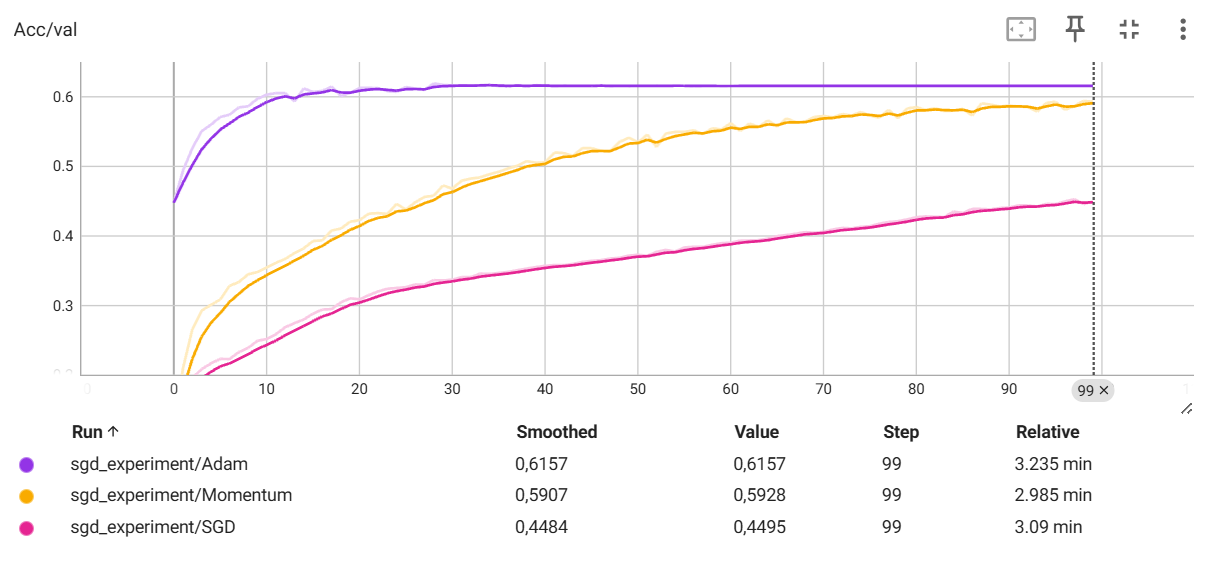
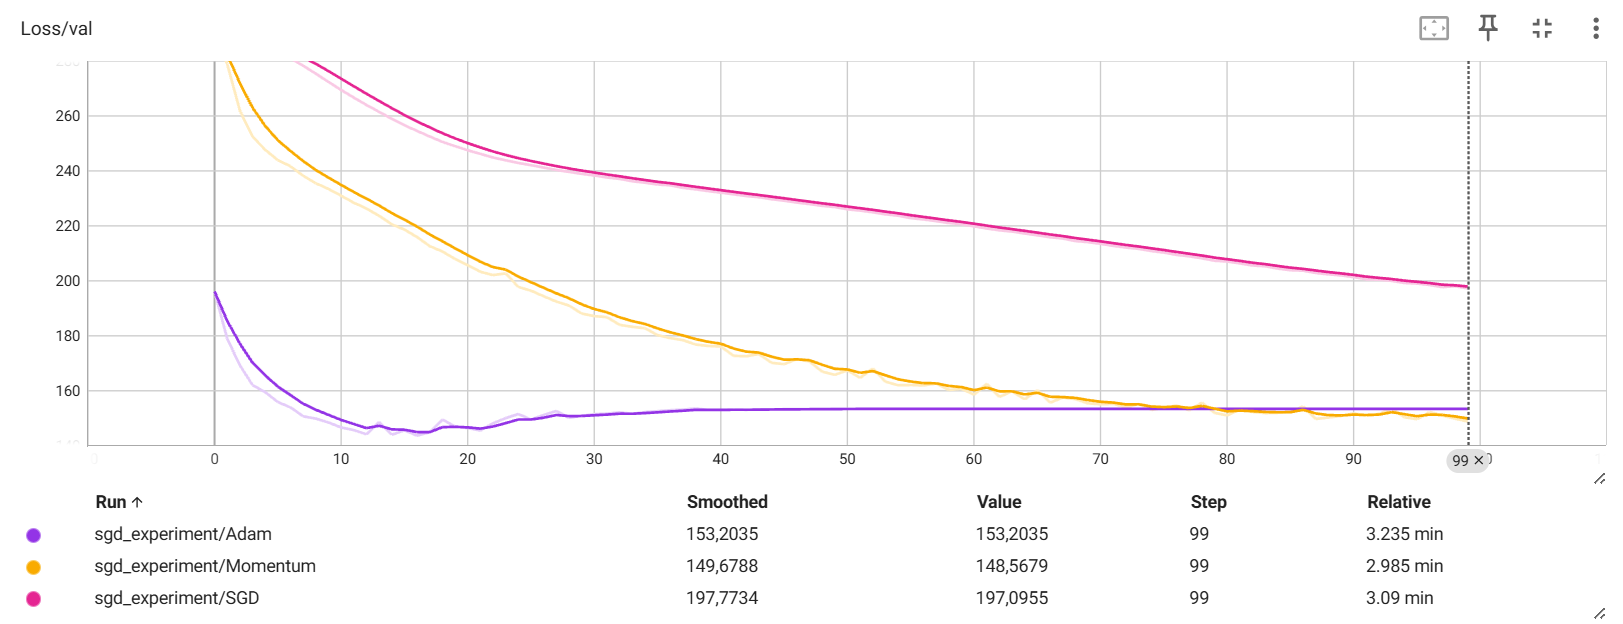

Как видно из графиков выше:  
Adam-grad очень быстро обучился до некого плато, но дальше не смог уменьшить лосс или увеличить точность. Обычный SGD-Momentum получил результаты лосса и accuracy лучше, чем Adam.

**Задание 5 (1.5 балл).** Добавьте нормализацию по батчу (`BatchNormalization`, `LayerNorm`) и просто нормализацию (`InstanceNorm`) между свёрткой и активацией. Попробуйте использовать несколько нормализаций — в свёрточных и полносвязных слоях. В чем отличе этих трёх нормализаций?

Ниже классы с одной нормализацией - только в свёртоном слое

In [47]:
class BatchNormCNN(PocketCNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=10,
                kernel_size=3
            ),
            
            nn.BatchNorm2d(10),  # Усредняет по каналам, ищет срденее и дисперсию по всему батчу на входе
            
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten()
        )

    

class InstanceNormCNN(PocketCNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=10,
                kernel_size=3
            ),
            
            nn.InstanceNorm2d(10),  # Усредняет по каналам, ищет срденее и дисперсию по каждому объекту отдельно
            
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten()
        )
        
        

Ниже классы с двуям нормализациями - в свёрточном и линейных слоях

In [48]:
class BatchNormCNNBatchNormLinear(BatchNormCNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.classifier = nn.Sequential(
            nn.Linear(2250, 100),
            
            nn.BatchNorm1d(100),
            
            nn.ReLU(),
            nn.Linear(100, 10),
            nn.Softmax(1)
        )



class InstanceNormCNNInstanceNormLinear(InstanceNormCNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.classifier = nn.Sequential(
            nn.Linear(2250, 100),
            
            nn.InstanceNorm1d(100),
            
            nn.ReLU(),
            nn.Linear(100, 10),
            nn.Softmax(1)
        )
        

In [ ]:
norm_eaxperiments ={
    "BatchNormCNN": {
        "create_model": BatchNormCNN,
        "loss_func": F.cross_entropy,
        "train_dl": train_dl,
        "val_dl": val_dl,
        "create_opt": torch.optim.SGD,
        "opt_args": {},
        "is_scheduler": True,
        "epochs": 100
    },
    
    "InstanceNormCNN": {
        "create_model": InstanceNormCNN,
        "loss_func": F.cross_entropy,
        "train_dl": train_dl,
        "val_dl": val_dl,
        "create_opt": torch.optim.SGD,
        "opt_args": {},
        "is_scheduler": True,
        "epochs": 100
    },
    
    "BatchNormCNNBatchNormLinear": {
        "create_model": BatchNormCNNBatchNormLinear,
        "loss_func": F.cross_entropy,
        "train_dl": train_dl,
        "val_dl": val_dl,
        "create_opt": torch.optim.SGD,
        "opt_args": {},
        "is_scheduler": True,
        "epochs": 100
    },
    
    "InstanceNormCNNInstanceNormLinear": {
        "create_model": InstanceNormCNNInstanceNormLinear,
        "loss_func": F.cross_entropy,
        "train_dl": train_dl,
        "val_dl": val_dl,
        "create_opt": torch.optim.SGD,
        "opt_args": {},
        "is_scheduler": True,
        "epochs": 100
    },
}

In [59]:
run_experiments(norm_eaxperiments, "norm_experiment")

I0000 00:00:1773418071.339558 2280110 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773418071.413381 2280110 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773418073.110468 2280111 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773418073.178184 2280111 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU in

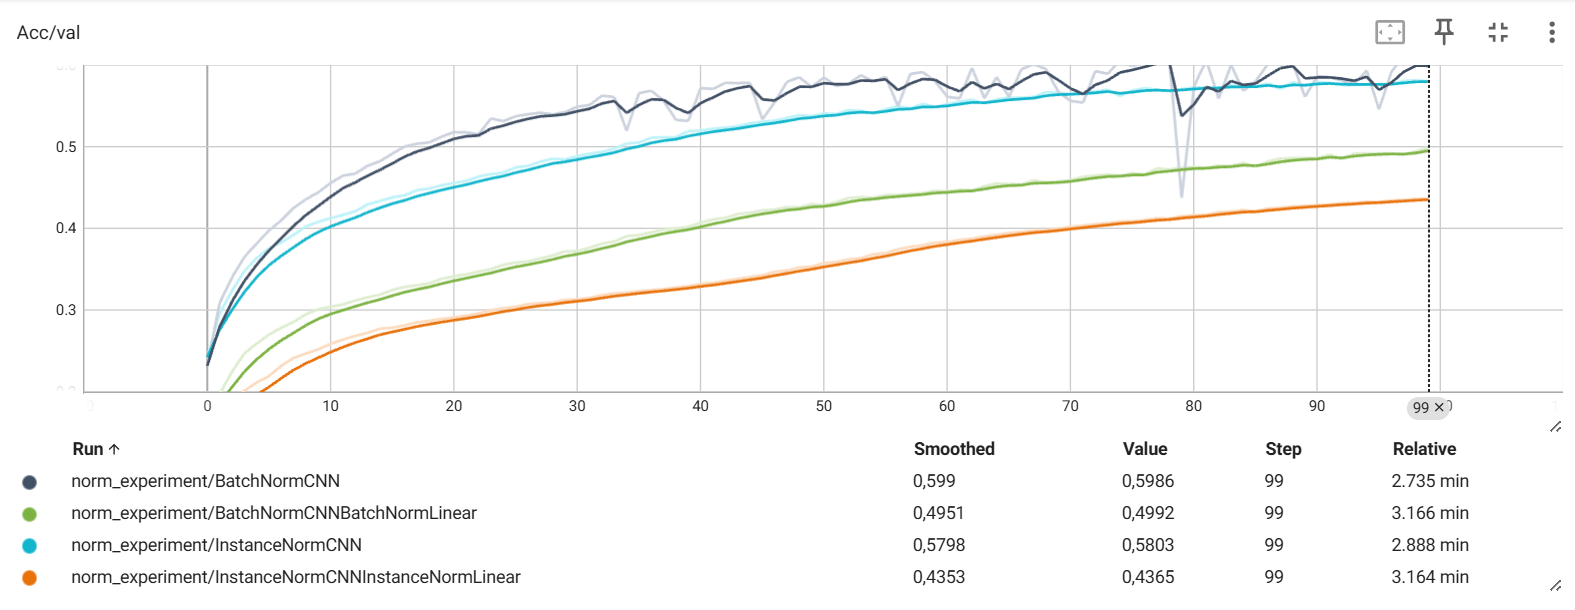
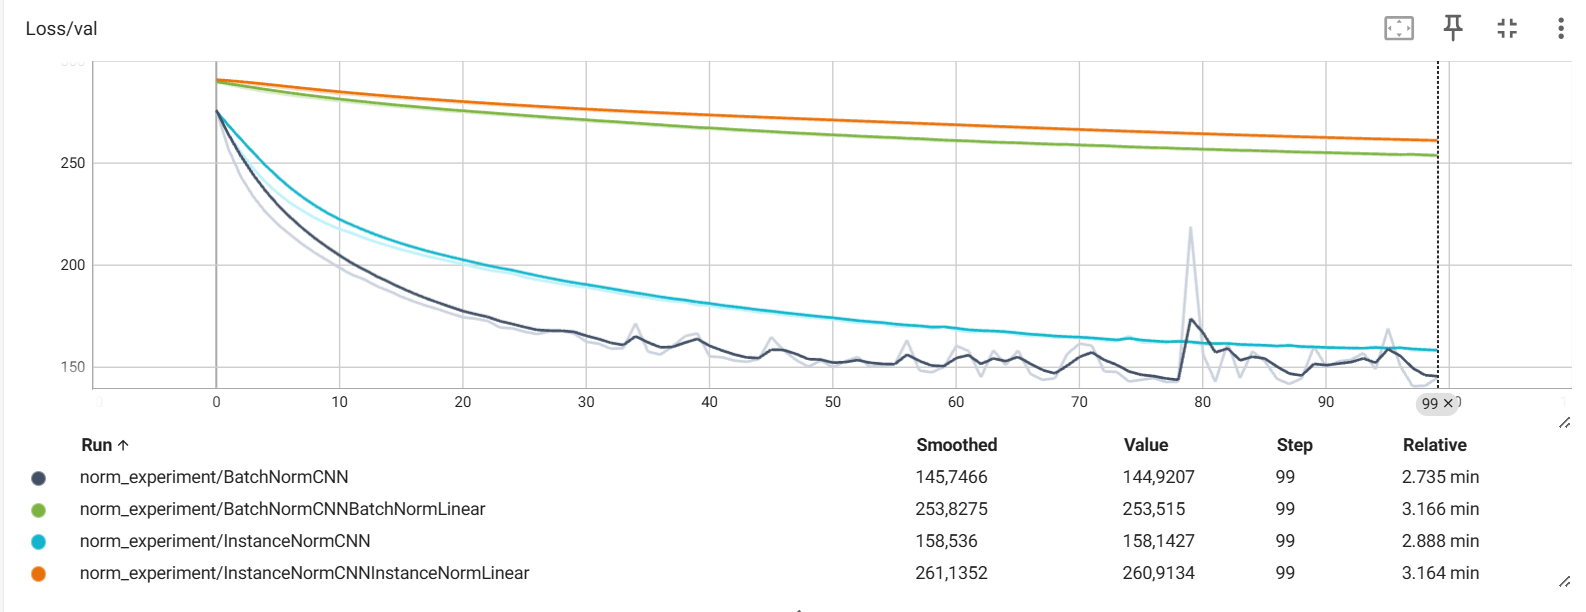

Как можно видеть из графиков выше:  
1. Лосс и acc у модельки с нормализацией только после свёртки стал немного шумный в процессе обучения. Возможно это связано с тем, что BatchNorm накапливает по время train скользящие статистики по X_train и потом применяет их при усреднении. Из за разных распределний данных на test и на val, обучение становится шумным, потому что сильно изменяется стандартизованные данные. При этом InstanceNorm после свёртки показывает такие же результаты лосса, при этом без сильного шума. Возможно это связано с тем, что статистики считаются по каждому объекту отдельно, что даёт более "усреднённое" скользящее среднее и дисперсию.

2. При этом, можно заметить, что если делать нормализацию после свёртки и полсе линейного слоя обучение происходит без сильного шума, но при этом, не достигается хорошего качества. Возможно это связано с тем, что нормализация после линейного слоя разрушает информацию о масштабе логитов.

**Задание 5.1 (1 балл).** Добавьте дропаут (`Dropout`). Попробуйте использовать нормализации — в свёрточных и полносвязных слоях. В какой конфигурации качество улучшилось, а в какой нет?

Появлется вопрос, в какое место ставить ```Dropout```, до или после нормализации??

Лучше ставить ```Dropout``` после нормализации, потому что нормализация накаплиывает в себе скользящее среднее и дисперсию, которые потом используются на инференсе. Поэтому, если мы добавим дропаут перед нормализацией статистики внутри нормализации поедут, и образуется variance-shift между test и train, поскольку дропаут отключается во время инференса и используется только для обучения.

In [60]:
class DropoutOnlyCNN(PocketCNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=10,
                kernel_size=3
            ),
            nn.ReLU(),
            
            nn.Dropout2d(),
            
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(2250, 100),
            nn.ReLU(),
            
            nn.Dropout1d(),
            
            nn.Linear(100, 10)
        )



class DropoutBatchNormCNN(PocketCNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=10,
                kernel_size=3
            ),
            nn.ReLU(),
            
            nn.BatchNorm2d(10),
            nn.Dropout2d(),
            
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(2250, 100),
            nn.ReLU(),
            
            nn.BatchNorm1d(100),
            nn.Dropout1d(),
            
            nn.Linear(100, 10)
        )



class DropoutInstanceNormCNN(PocketCNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=10,
                kernel_size=3
            ),
            nn.ReLU(),
            
            nn.InstanceNorm2d(10),
            nn.Dropout2d(),
            
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(2250, 100),
            nn.ReLU(),
            
            nn.LayerNorm(100),
            nn.Dropout1d(),
            
            nn.Linear(100, 10)
        )
        
        

In [ ]:
dropout_experiments = {
    "DropoutOnlyCNN": {
        "create_model": DropoutOnlyCNN,
        "loss_func": F.cross_entropy,
        "train_dl": train_dl,
        "val_dl": val_dl,
        "create_opt": torch.optim.SGD,
        "opt_args": {},
        "is_scheduler": True,
        "epochs": 100
    },
    
    "DropoutBatchNormCNN": {
        "create_model": DropoutBatchNormCNN,
        "loss_func": F.cross_entropy,
        "train_dl": train_dl,
        "val_dl": val_dl,
        "create_opt": torch.optim.SGD,
        "opt_args": {},
        "is_scheduler": True,
        "epochs": 100
    },
    
    "DropoutInstanceNormCNN": {
        "create_model": DropoutInstanceNormCNN,
        "loss_func": F.cross_entropy,
        "train_dl": train_dl,
        "val_dl": val_dl,
        "create_opt": torch.optim.SGD,
        "opt_args": {},
        "is_scheduler": True,
        "epochs": 100
    },
}

In [66]:
run_experiments(dropout_experiments, "dropout_experiment")

  0%|          | 0/100 [00:00<?, ?it/s]


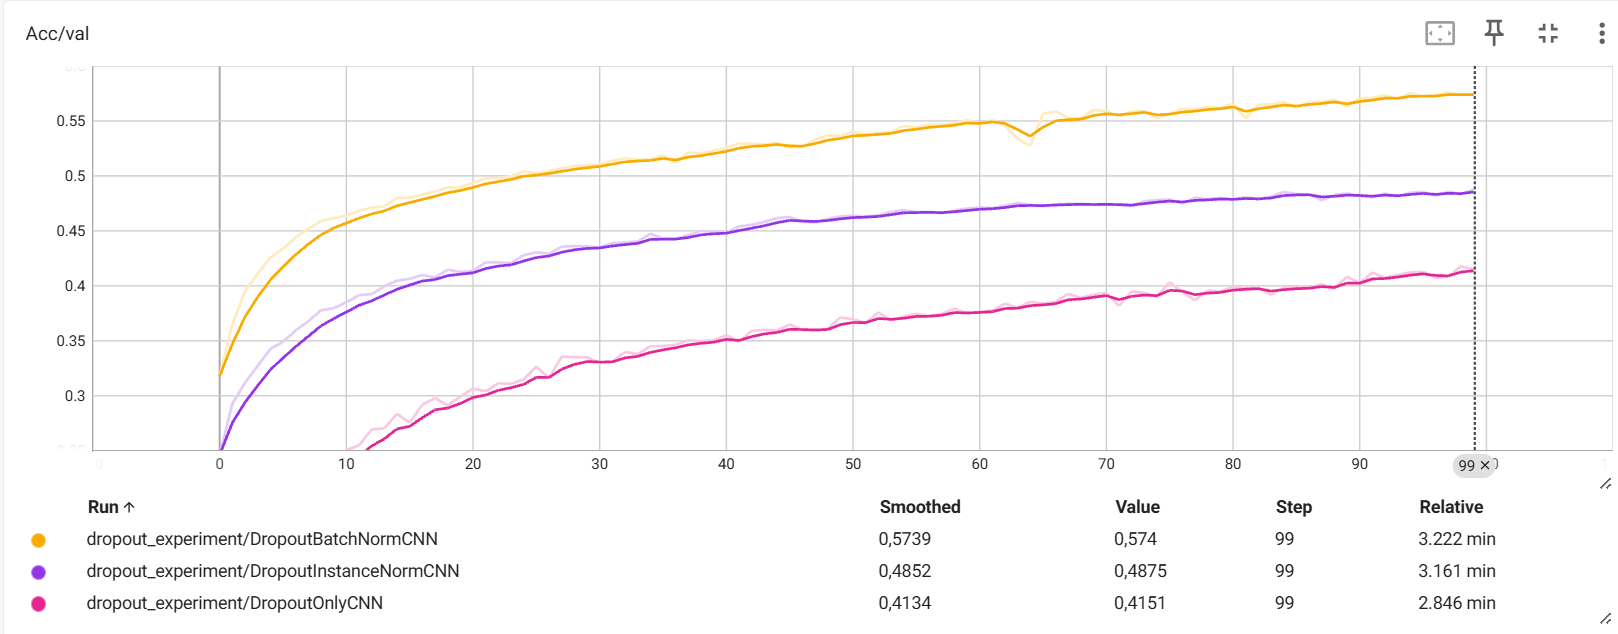
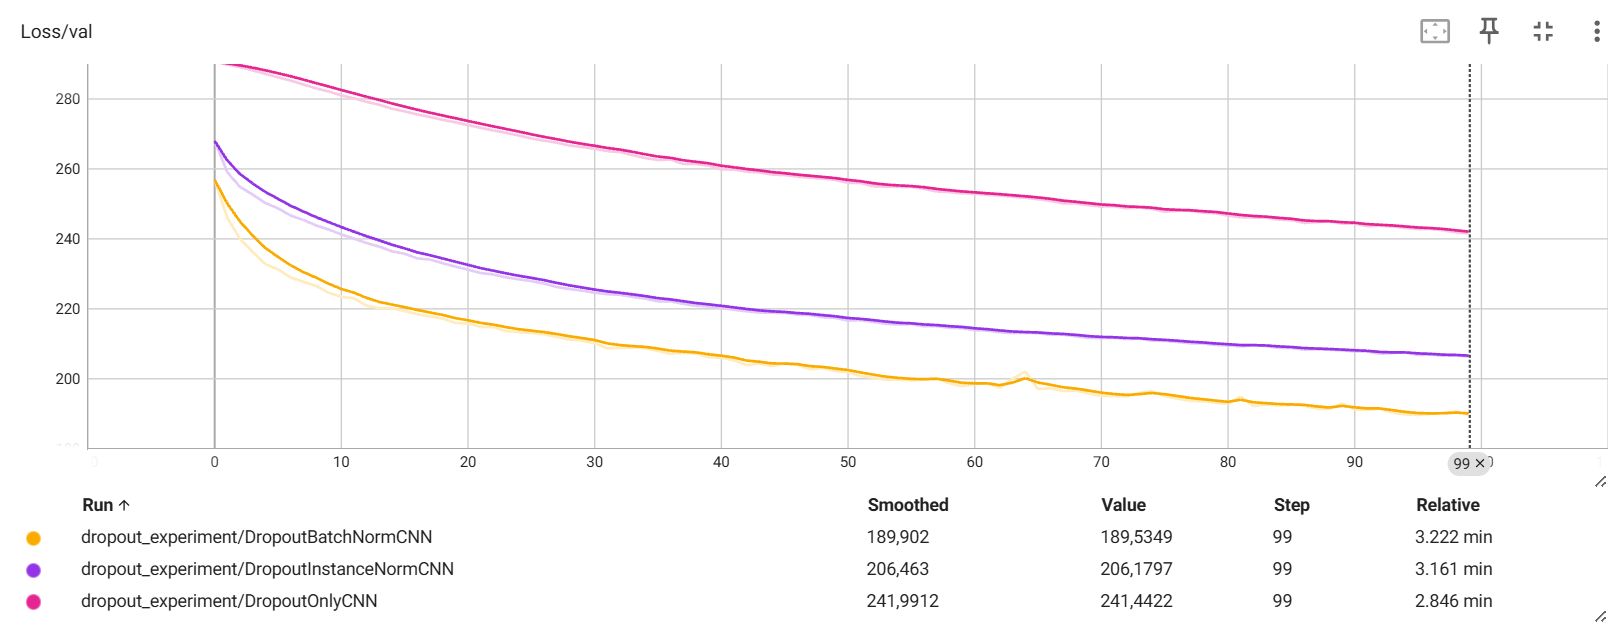

Как можно видеть из графиков выше:
1. Добавление простого DropOut без какой либо нормализации показывает себя хуже всего.

2. Лучше всего показывает себя BatchNorm после CNN вместе с DropOut. Вообще на DropOut можно смотреть как на обучение целого ансамбля нейронных сетей. Если у нас есть $n$ неронов, то, при всевозможных выключениях и включениях нейронов, всего у нас $2^n$ подсетей, которые мы обучаем, применяя к исходной сети DropOut. В итоге получается, что при инференсе мы усредняем обученные нами подсети. И BatchNorm помогает делать усреднение лучше, используя скользящие средние, накопленные за всевозможные варианты подсетей. Важно ставить нормализацию именно до DropOut, иначе последний будет портить статистики накапленные в BatchNorm.

**Задание 5.2 (1 балл).** Посмотрите на batch_size - при большем батче модель будет быстрее проходить эпохи, но с совсем огромным батчем вам потребуется больше эпох для сходимости (т.к. сеть делает меньше шагов за одну эпоху).
Найдите такое значение, при котором модель быстрее достигает точности 55%.

In [ ]:
batch_experiments = {}
batch_sizes = [32, 64, 128, 256, 1024]

for bs in batch_sizes:
    batch_experiments[f"PocketCNN_bs_{bs}"] = {
        "create_model": PocketCNN,
        "loss_func": F.cross_entropy,
        "train_dl": DataLoader(train_ds, batch_size=bs),
        "val_dl": DataLoader(valid_ds, batch_size=bs),
        "create_opt": torch.optim.SGD,
        "opt_args": {},
        "is_scheduler": True,
        "epochs": 100
    }

In [68]:
run_experiments(batch_experiments, "batch_experiment")

I0000 00:00:1773422532.428823 2589155 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773422532.494684 2589155 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773422534.403760 2589155 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773422534.564883 2589156 port.cc:153] oneDNN custom operations are on. You may see slightly different numerica

  0%|          | 0/100 [00:00<?, ?it/s]


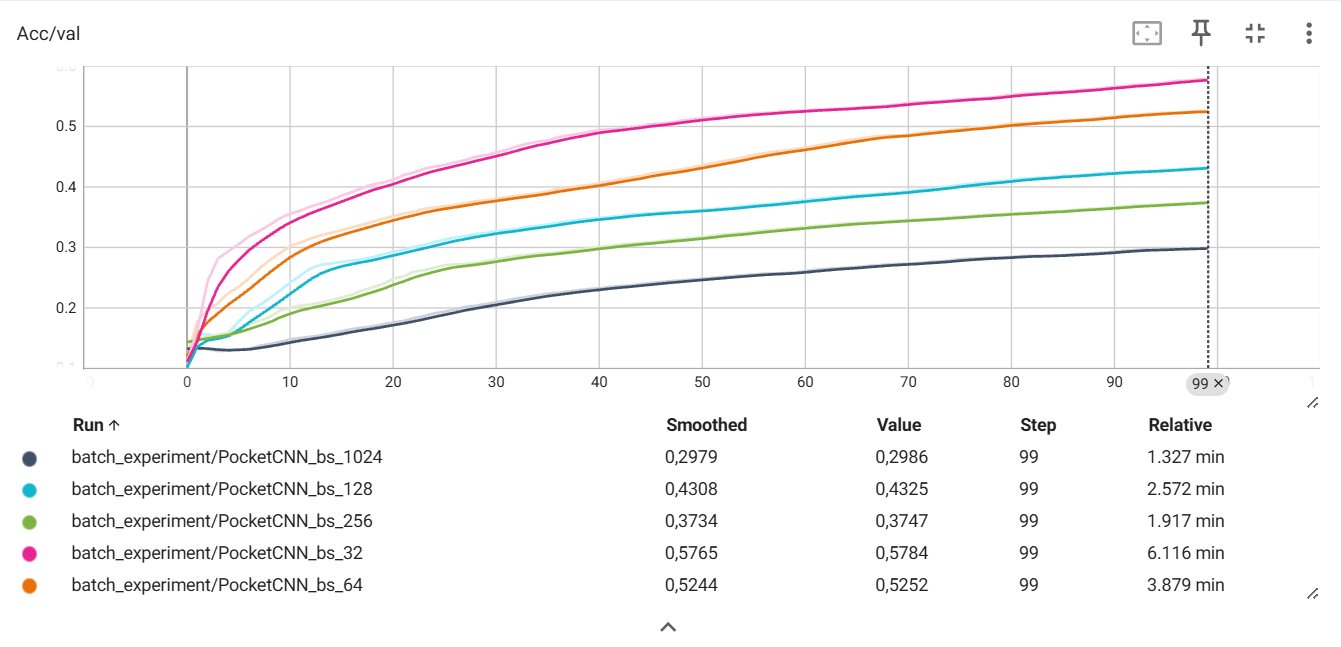
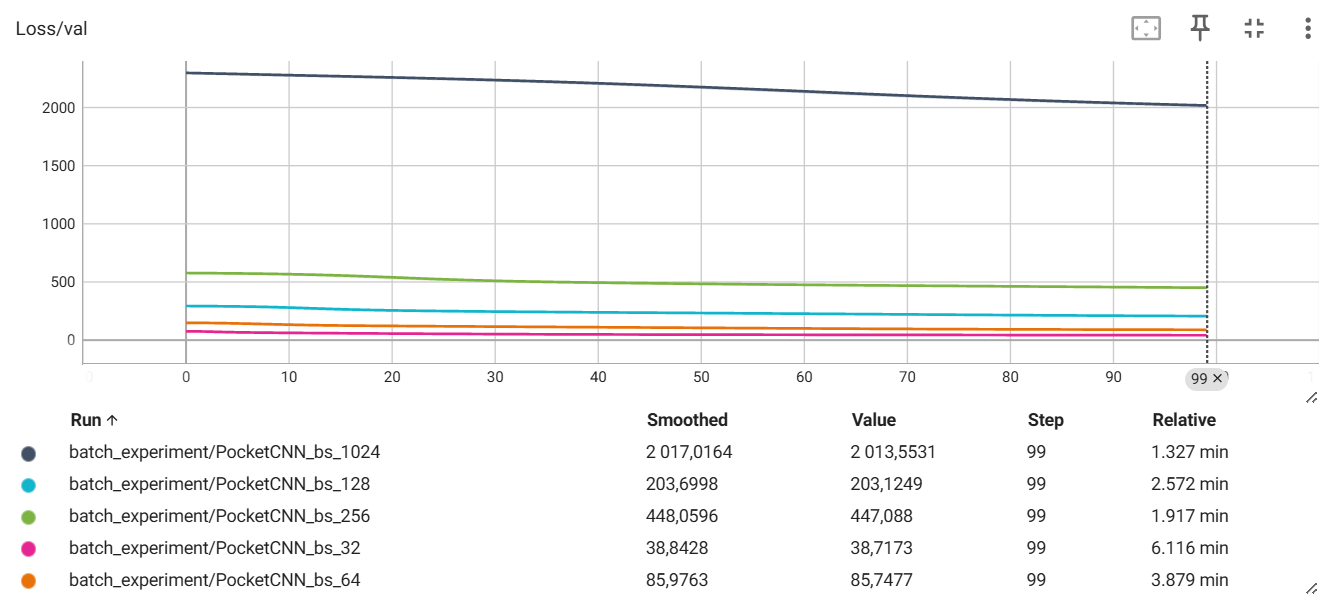

Как видно из графиков выше:  
1. Быстрее всего acc больше 55% достигается для самого маленького batch_size (32). Связано это с тем, что модель делает больше шагов во время обучения, что делает сходимость быстрее (нужно меньше эпох). 

**Задание 6 (1 балл).** Попробуйте найти такую комбинацию метода обучения и нормализации, при которой сеть имеет наилучшую кривую обучения. Поясните, что вы понимаете под "наилучшей" кривой обучения.

In [69]:
class BestLearningCNN(PocketCNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=10,
                kernel_size=3
            ),
            nn.ReLU(),
            nn.BatchNorm2d(10),
            nn.Dropout2d(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(2250, 100),
            nn.ReLU(),
            nn.BatchNorm1d(100),
            nn.Dropout1d(),
            nn.Linear(100, 10)
        )


In [ ]:
best_learning_experiment = {
    "best_learning_experiment": 
    {
        "create_model": BestLearningCNN,
        "loss_func": F.cross_entropy,
        "train_dl": DataLoader(train_ds, batch_size=32),
        "val_dl": DataLoader(valid_ds, batch_size=32),
        "create_opt": torch.optim.SGD,
        "opt_args": {
                "momentum": 0.85
            },
        "is_scheduler": True,
        "epochs": 100
    }
}

In [73]:
run_experiments(best_learning_experiment, "best_learning")

I0000 00:00:1773424463.230791 3010854 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773424463.288085 3010854 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773424464.992524 3010854 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


  0%|          | 0/100 [00:00<?, ?it/s]


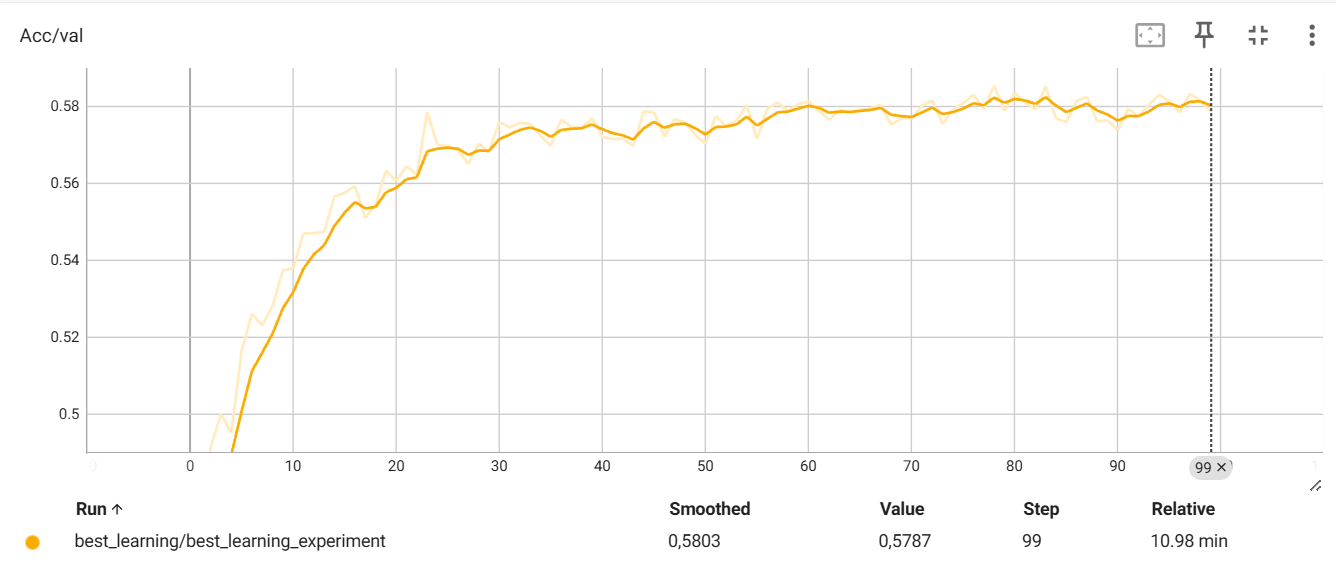
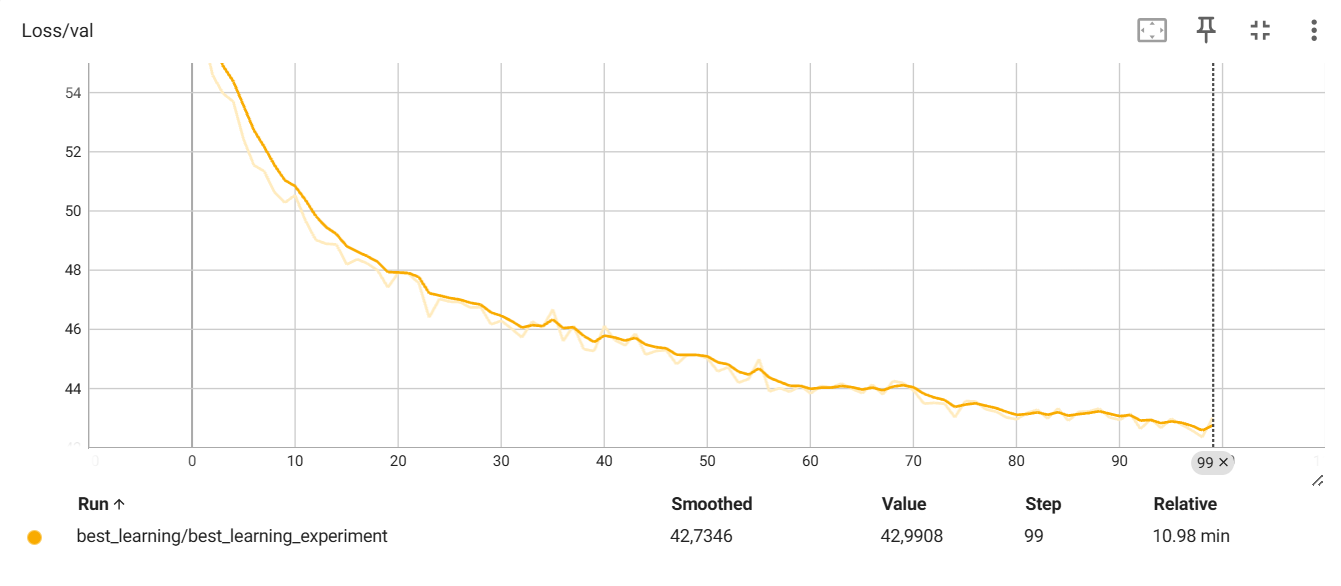

Как я понимаю "хорошую" кривую обучения как кривую на графике без сильного шума, и монотонно убывающую. Собвстенно, это мы и видим на графике) 

Что я сделал:
1. Добавил BatchNorm вместе с DropOut после свёртки и после линейного слоя.
2. Использовал SGD-Momentum c гиперпараметром 0.8
3. Использовал маленький batch_size = 32

Напишите ваши выводы по проделанным экспериментам: что заработало, что — не очень. Постройте графики кривых обучения разных архитектур.

Мне понравилось проводить эксперименты, и мне кажется, Что я написал для этого достаточно хорший pipline.  По данным экспериментам можно увидеть, как сильно влияют добавление 1-го слоя на обучение модели или изменение размера батча.  Вообще лабораторные это круто и прикольно, но было бы классно, если бы ещё давали какие то архитектурные (именно по написанию кода) рекомендации, потому что не всегда заранее понимаешь, как лучше и удобней написать пайплайн для конкретных экспериментов или как это делают, например в продакшене.

## Свёрточная нейросеть здорового человека

**Задание 7 (7 баллов).** Наигравшись выше, обучим большую свёрточную сеть, которая даст на тестовой выборке __accuracy больше 80%__. В этом задании вам потребуется провести эксперименты, сравнив их между собой в конце. Возможно, будет несколько проще, если писать выводы во время или сразу после каждого эксперимента, после чего сделать общие выводы.

Критерии:
- за качество вы получите 4 балла, если преодолеете порог
- за анализ архитектур, подходов, аугментаций получете дополнительные 3 балла. Возможно, анализ стоит делать не по ходу, а для лучшей архитектуры.

Рекомендуем начать с лучшей модели предыдущего задания и постепенно её улучшать. Вы можете использовать всё, что угодно: любые активации, сколь угодно большие свёрточные слои и глубокие сети. Единственное ограничение: __нельзя использовать предобученные сети и дополнительные данные__.

### Полезные советы
* Для начала неплохо бы научить что-нибудь побольше, чем 10 фильтров 3x3.
* __Главное правило: одно изменение на эксперимент__. Если у вас есть 2 идеи по улучшению сети, сначала попробуйте их независимо. Может оказаться, что одно из них дало __+10%__ точности, а другое __-7%__. А вы так и будете думать, что сделали 2 полезных изменения, которые в сумме дают __+3%__. Если какая-то идея не работает — даже если она вам нравится - опишите ее и выкидывайте из дальнейших экспериментов.
* __Be careful or you will dropout__. Дропаут (`torch.nn.Dropout`) может позволить вам обучить в несколько раз бОльшую сеть без переобучения, выжав несколько процентов качества. Это круто, но не стоит сразу ставить dropout 50%. Во-первых, слишком сильный дропаут только ухудшит сеть (underfitting). Во-вторых, даже если дропаут улучшает качество, он замедляет обучение. Рекомендуем начинать с небольшого дропаута, быстро провести основные эксперименты, а потом жахнуть в 2 раза больше нейронов и дропаута ~~на ночь~~.
* __Аугментация данных__. Если котика слегка повернуть и подрезать (простите), он всё равно останется котиком. Рекомендуем albumentations.
* __Don't just stack more layers__. Есть более эффективные способы организовать слои, чем простой Sequential. Вот пара идей: [Inception family](https://hacktildawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://sheng-fang.github.io/2020-05-20-review-resnet-family/), [Densely-connected convolutions](https://arxiv.org/abs/1608.06993). Только не копируйте архитектуру подчистую — вам скорее всего хватит меньшего размера. Например, в resnet можно воспользоваться блоками, без первых свёрток которые сильно уменьшают пространственную размерность, так как у нас итак картинки 32x32.
* __Долго != плохо__. Более глубокие архитектуры обычно требуют бОльше эпох до сходимости. Это значит, что в первые несколько эпох они могут быть хуже менее глубоких аналогов. Дайте им время, запаситесь чаем и обмажьтесь batch-norm-ом.
* __Не используйте timm__. Зачастую многие архитектуры уже за вас реализованы и вам достаточно импортировать из либы нужную модель, например через [pytorch_image_models](https://github.com/huggingface/pytorch-image-models) или `torchvision.models`. В семинаре использование подобных библиотек не разрешается, все архитектуры нужно реализовать руками, отнаследовавшись от `torch.nn.Module`.

In [364]:
class BestCNNv1(PocketCNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=5),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(in_channels=96, out_channels=128, kernel_size=3),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=4, stride=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            
            nn.MaxPool2d(kernel_size=4, stride=2),
            nn.Flatten()
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(4608, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(2048, 10)
        )




class BestCNNv2(PocketCNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=5),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(in_channels=96, out_channels=128, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=4, stride=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3),
            nn.ReLU(inplace=True),
            
            nn.MaxPool2d(kernel_size=4, stride=2),
            nn.Flatten()
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(4608, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(2048, 10)
        )



class BestCNNv3(PocketCNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=3),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(in_channels=96, out_channels=128, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=4, stride=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3),
            nn.ReLU(inplace=True),
            
            nn.MaxPool2d(kernel_size=4, stride=2),
            nn.Flatten()
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(4608, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(2048, 10)
        )



class BestCNNv4(PocketCNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=3),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(in_channels=96, out_channels=128, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=4, stride=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3),
            nn.ReLU(inplace=True),
            
            nn.MaxPool2d(kernel_size=4, stride=2),
            nn.Flatten()
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(4608, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(2048, 10)
        )
        

In [369]:
# m = BestCNNv4()
# m(X_train_aug[:10])

Тесты будем проводить сразу на аугментированных данных, которые создали в начали ноутбука.

In [370]:
best_experiment = {
    "best_cnn_v1": {
        "create_model": BestCNNv1,
        "loss_func": F.cross_entropy,
        "train_dl": DataLoader(train_aug_ds, batch_size=32),
        "val_dl": DataLoader(valid_ds, batch_size=32),
        "create_opt": torch.optim.SGD,
        "opt_args": {
                "momentum": 0.9
            },
        "is_scheduler": False,
        "epochs": 40
    },
    
    "best_cnn_v2": {
        "create_model": BestCNNv2,
        "loss_func": F.cross_entropy,
        "train_dl": DataLoader(train_aug_ds, batch_size=32),
        "val_dl": DataLoader(valid_ds, batch_size=32),
        "create_opt": torch.optim.SGD,
        "opt_args": {
                "momentum": 0.9
            },
        "is_scheduler": False,
        "epochs": 40
    },
    
    "best_cnn_v3": {
        "create_model": BestCNNv3,
        "loss_func": F.cross_entropy,
        "train_dl": DataLoader(train_aug_ds, batch_size=32),
        "val_dl": DataLoader(valid_ds, batch_size=32),
        "create_opt": torch.optim.SGD,
        "opt_args": {
                "momentum": 0.9
            },
        "is_scheduler": False,
        "epochs": 40
    },
    
    "best_cnn_v4": {
        "create_model": BestCNNv4,
        "loss_func": F.cross_entropy,
        "train_dl": DataLoader(train_aug_ds, batch_size=32),
        "val_dl": DataLoader(valid_ds, batch_size=32),
        "create_opt": torch.optim.SGD,
        "opt_args": {
                "momentum": 0.9
            },
        "is_scheduler": False,
        "epochs": 40
    }
}

In [371]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "5,6"

In [372]:
run_experiments(best_experiment, "best_experiment")

I0000 00:00:1773479528.148494 1273236 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773479528.212593 1273236 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773479530.207809 1273236 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773479532.837917 1273286 port.cc:153] oneDNN custom operations are on. You may see slightly different numerica

KeyboardInterrupt: 

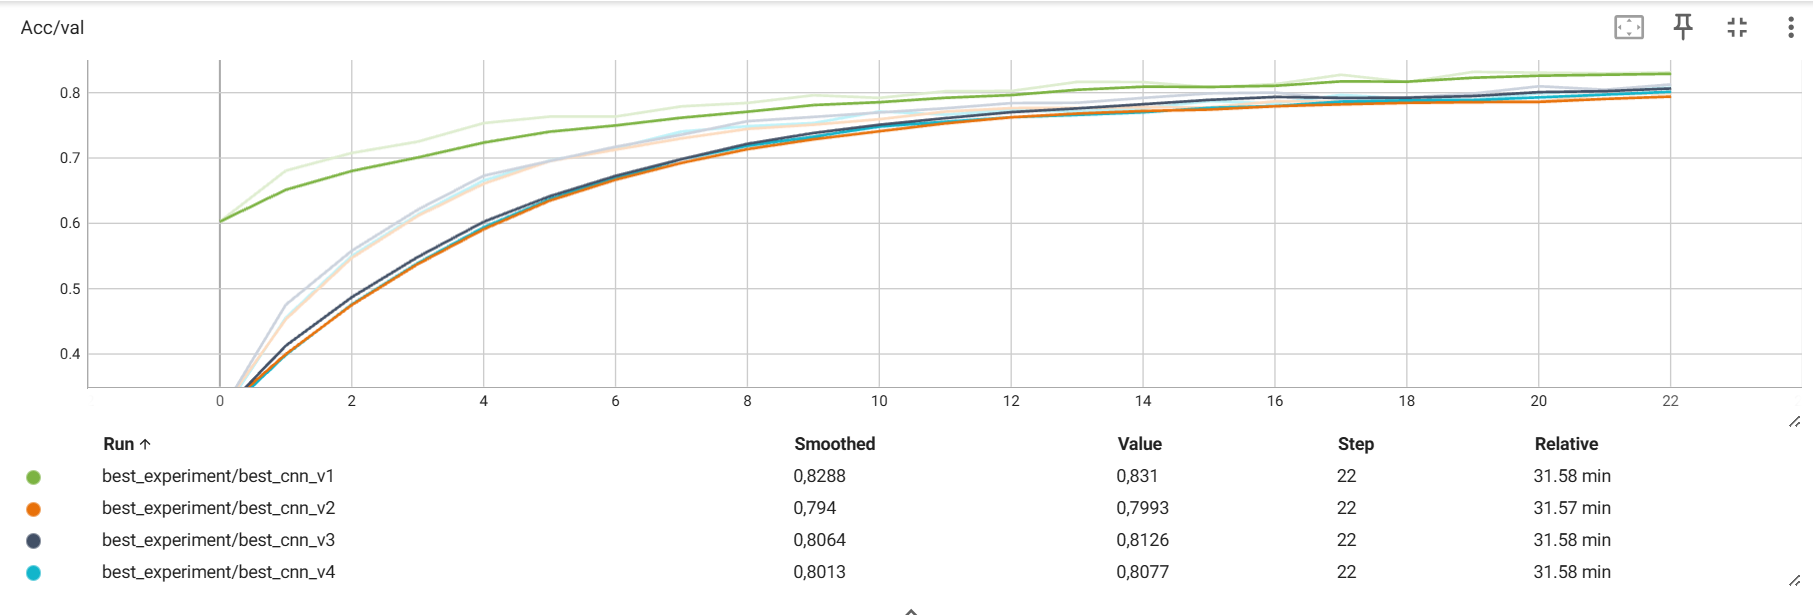
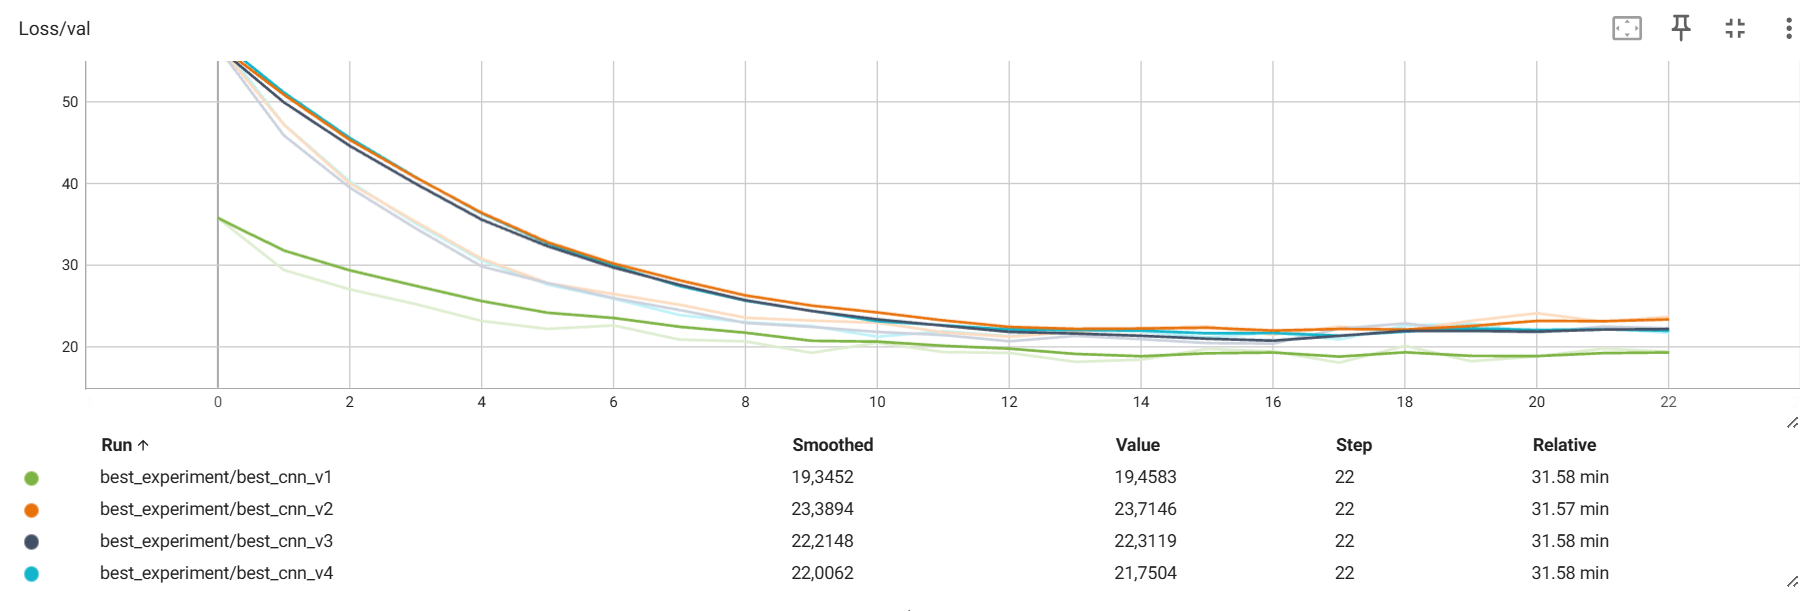

Посмотрев на графики выше, можно заметить, что наилучшую привую обучения и кривую acc имеет ```BestCNNv1```, её и будем обучать.

In [375]:
best_model = BestCNNv1()
train_aug_dl = DataLoader(train_aug_ds, batch_size=32)
opt = torch.optim.SGD(best_model.parameters(), momentum=0.9)
writer = SummaryWriter("runs/best_experiment/final")

fit(25, best_model, F.cross_entropy, opt, train_aug_dl, val_dl, writer, verbose=True)

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 000 Train_loss: 46.7331 Val_loss: 140.4340 Val_acc: 0.6118 LR: 1.00e-03
Epoch: 001 Train_loss: 35.0161 Val_loss: 119.9473 Val_acc: 0.6728 LR: 1.00e-03
Epoch: 002 Train_loss: 30.1015 Val_loss: 104.8810 Val_acc: 0.7119 LR: 1.00e-03
Epoch: 003 Train_loss: 26.6540 Val_loss: 98.3354 Val_acc: 0.7368 LR: 1.00e-03
Epoch: 004 Train_loss: 24.1413 Val_loss: 89.5059 Val_acc: 0.7587 LR: 1.00e-03
Epoch: 005 Train_loss: 22.0362 Val_loss: 86.2777 Val_acc: 0.7670 LR: 1.00e-03
Epoch: 006 Train_loss: 20.1687 Val_loss: 86.1048 Val_acc: 0.7741 LR: 1.00e-03
Epoch: 007 Train_loss: 18.4708 Val_loss: 81.2679 Val_acc: 0.7859 LR: 1.00e-03
Epoch: 008 Train_loss: 17.1113 Val_loss: 81.7003 Val_acc: 0.7883 LR: 1.00e-03
Epoch: 009 Train_loss: 15.8031 Val_loss: 81.8730 Val_acc: 0.7893 LR: 1.00e-03
Epoch: 010 Train_loss: 14.4852 Val_loss: 78.4784 Val_acc: 0.7984 LR: 1.00e-03
Epoch: 011 Train_loss: 13.3859 Val_loss: 71.6597 Val_acc: 0.8157 LR: 1.00e-03
Epoch: 012 Train_loss: 12.4394 Val_loss: 73.0307 Val_acc: 0.8

Момент истины: проверьте, какого качества достигла ваша сеть.

In [381]:
from sklearn.metrics import accuracy_score
best_model.to("cpu")
test_acc = accuracy_score(y_test, best_model.predict_classes(X_test))
print("\n Test_acc =", test_acc)
if test_acc > 0.8:
    print("Это победа!")


 Test_acc = 0.8397
Это победа!


А теперь, опишите свои <s>ощущения</s> результаты от проведенных экспериментов. 

Честно, экспериментировать было довольно интересно, особенно, если написать удобный для этого pipeline и использовать TensorBoard.  

Результаты экспериментов:  
Моя лучшая модель, которая пробила порог в 80% имеет следующую архитектуру:
1. 4 свёрточных слоя + нормализация + MaxPool в середине и в конце
2. Линейный слой с двумы Dropout'ами, для регуляризации неронной сети  

Помимо этого я обучал лучшую модель на аугментированных данных. В аугментации я использовал поворот и контраст цветов, чего в принципе хватило для пробития порога.  

Также, можно сделать вывод, по последнему эксперименту, что нормализация довольно важная вещь в свёрточных слоях.